<a href="https://colab.research.google.com/github/vs-pooja/titanic_survival/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install kagglehub


In [ ]:
from kagglehub import kagglehub
path=kagglehub.dataset_download("yasserh/titanic-dataset")
print(path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
/kaggle/input/titanic-dataset


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [ ]:
data=pd.read_csv(f"{path}/Titanic-Dataset.csv")
data.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
num_data=data[['Age','Fare','SibSp','Parch']]
num_data.head()

,Age,Fare,SibSp,Parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


In [ ]:
num_data.isnull().sum()

,0
Age,177
Fare,0
SibSp,0
Parch,0


In [ ]:
num_data=num_data.dropna()
num_data.shape

(714, 4)

In [ ]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(num_data)
scaled_data

array([[-0.53037664, -0.51897787,  0.52457013, -0.50589515],
       [ 0.57183099,  0.69189675,  0.52457013, -0.50589515],
       [-0.25482473, -0.50621356, -0.55170307, -0.50589515],
       ...,
       [-0.73704057, -0.08877362, -0.55170307, -0.50589515],
       [-0.25482473, -0.08877362, -0.55170307, -0.50589515],
       [ 0.15850313, -0.50952283, -0.55170307, -0.50589515]])

In [ ]:
pca=PCA(n_components=2)
pca.fit(scaled_data)
pca_data=pca.transform(scaled_data)
pca_data

array([[ 0.12686053, -0.84897828],
       [-0.04214126,  0.75209689],
       [-0.66350728, -0.59590003],
       ...,
       [-0.34337724, -0.55801703],
       [-0.55500798, -0.27049992],
       [-0.84576519, -0.35203641]])

In [ ]:
pca1=pca_data[:,0]
pca2=pca_data[:,1]

In [ ]:
import matplotlib.pyplot as plt

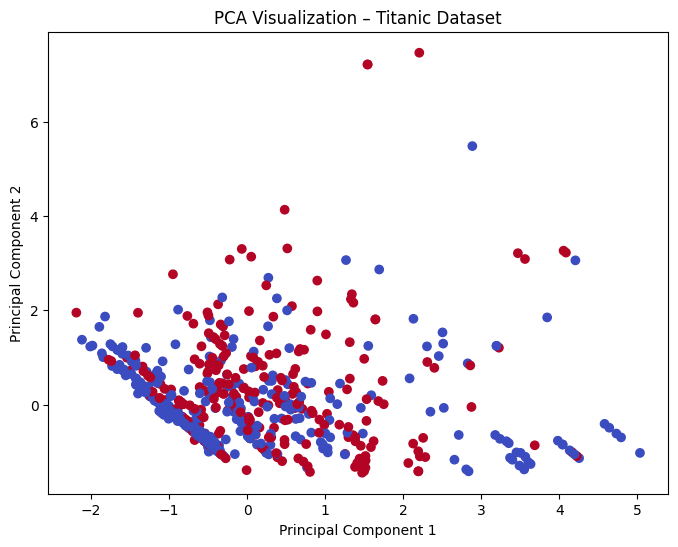

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(pca1, pca2, c=data.loc[num_data.index, 'Survived'], cmap='coolwarm')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization – Titanic Dataset")
plt.show()

In [ ]:
print(f"Explained Variance Ratio by PC1 & PC2: {pca.explained_variance_ratio_}")

Explained Variance Ratio by PC1 & PC2: [0.40918758 0.27679424]
